In [1]:
import glob
from pathlib import Path
from typing import Callable, Optional

import pandas as pd
import seaborn as sns
import numpy as np

### Preprocessing Validation

In [ ]:
# Read index from all parts matching a pattern and verify that the indexes do not overlap


def test_index_overlap(pattern: str):
    indexes = [set(pd.read_feather(f, columns=["kmer"]).index) for f in glob.glob(pattern)]

    print(f"Found {len(indexes)} indexes containing {sum(len(idx) for idx in indexes)} from files matching pattern: {pattern}")

    for i in range(len(indexes)):
        for j in range(i+1, len(indexes)):
            assert indexes[i].isdisjoint(indexes[j]), f"Indexes overlap detected"

In [7]:
test_index_overlap('../data/hamburg/joined-counts/Col_aColaLer.joined.part.*.feather')

Found 5 indexes containing 107442395 from files matching pattern: ../data/hamburg/joined-counts/Col_aColaLer.joined.part.*.feather


In [3]:
df = pd.read_feather('../data/hamburg/joined-counts/Col_ColLer.joined.index.feather')
df.shape

(76263426, 1)

In [6]:
df.dtypes

part    int64
dtype: object

### Correlation

In [2]:
df_g = pd.read_csv('../data/hamburg/cen-genotypes/C_LC.cen-genotype.csv', index_col=0)
df_g

,1,2,3,4,5
Sample,,,,,
C-LC-1,A,H,H,A,H
C-LC-10,A,H,H,H,H
C-LC-100,A,H,H,H,H
C-LC-101,H,H,A,H,A
C-LC-102,A,A,A,A,A
...,...,...,...,...,...
C-LC-95,H,H,H,A,A
C-LC-96,H,H,H,H,A
C-LC-97,A,H,A,A,A


In [3]:
# filter rows that contain value other than A or H
df_g = df_g[df_g.apply(lambda x: x.isin(['A', 'H']).all(), axis=1)]
print(pd.Series(df_g.values.flatten()).value_counts())
df_g

A    279
H    276
Name: count, dtype: int64


,1,2,3,4,5
Sample,,,,,
C-LC-1,A,H,H,A,H
C-LC-10,A,H,H,H,H
C-LC-100,A,H,H,H,H
C-LC-101,H,H,A,H,A
C-LC-102,A,A,A,A,A
...,...,...,...,...,...
C-LC-95,H,H,H,A,A
C-LC-96,H,H,H,H,A
C-LC-97,A,H,A,A,A


In [4]:
df_g.rename(index=lambda x: x.replace('-', '_'), inplace=True)
df_g

/tmp/ipykernel_3292628/1955428213.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_g.rename(index=lambda x: x.replace('-', '_'), inplace=True)


,1,2,3,4,5
Sample,,,,,
C_LC_1,A,H,H,A,H
C_LC_10,A,H,H,H,H
C_LC_100,A,H,H,H,H
C_LC_101,H,H,A,H,A
C_LC_102,A,A,A,A,A
...,...,...,...,...,...
C_LC_95,H,H,H,A,A
C_LC_96,H,H,H,H,A
C_LC_97,A,H,A,A,A


In [5]:
df_g = df_g.map(lambda x: {"A": 0, "H": 1}.get(x, x))
print(df_g.dtypes)
df_g

1    int64
2    int64
3    int64
4    int64
5    int64
dtype: object


,1,2,3,4,5
Sample,,,,,
C_LC_1,0,1,1,0,1
C_LC_10,0,1,1,1,1
C_LC_100,0,1,1,1,1
C_LC_101,1,1,0,1,0
C_LC_102,0,0,0,0,0
...,...,...,...,...,...
C_LC_95,1,1,1,0,0
C_LC_96,1,1,1,1,0
C_LC_97,0,1,0,0,0


In [6]:
df_meta = pd.read_csv('../PRJNA723952.SraRunTable.csv', index_col=['Run'])
df_meta.head()

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,Consent,DATASTORE filetype,...,LibrarySelection,LibrarySource,Organism,Platform,ReleaseDate,create_date,version,Sample Name,SRA Study,tissue
Run,,,,,,,,,,,,,,,,,,,,,
SRR14315885,WGS,300,231042600,PRJNA723952,SAMN18854919,Plant,99761957,UNIVERSITY OF CALIFORNIA DAVIS,public,"run.zq,sra,fastq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_ta_21,SRP315964,Leaf
SRR14315886,WGS,300,223972800,PRJNA723952,SAMN18854918,Plant,97450554,UNIVERSITY OF CALIFORNIA DAVIS,public,"fastq,sra,run.zq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_ta_20,SRP315964,Leaf
SRR14315887,WGS,300,224124900,PRJNA723952,SAMN18854624,Plant,96114811,UNIVERSITY OF CALIFORNIA DAVIS,public,"sra,fastq,run.zq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_aa_94,SRP315964,Leaf
SRR14315888,WGS,300,161992800,PRJNA723952,SAMN18854623,Plant,69335042,UNIVERSITY OF CALIFORNIA DAVIS,public,"sra,run.zq,fastq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_aa_93,SRP315964,Leaf
SRR14315889,WGS,300,222033000,PRJNA723952,SAMN18854621,Plant,94046947,UNIVERSITY OF CALIFORNIA DAVIS,public,"sra,run.zq,fastq",...,RANDOM,GENOMIC,Arabidopsis thaliana,ILLUMINA,2022-07-18T00:00:00Z,2021-04-24T08:53:00Z,1,C_aa_91,SRP315964,Leaf


In [7]:
df = pd.read_feather('../data/hamburg/joined-counts/Col_ColLer.joined.part.1.feather')
df.shape

(38133939, 110)

In [8]:
df.rename(columns=lambda run: df_meta.loc[run, 'Sample Name'], inplace=True)
df.columns

Index(['C_LC_29', 'C_LC_87', 'C_LC_83', 'C_LC_63', 'C_LC_92', 'C_LC_93',
       'C_LC_45', 'C_LC_54', 'C_LC_70', 'C_LC_82',
       ...
       'C_LC_79', 'C_LC_4', 'C_LC_108', 'C_LC_117', 'C_LC_52', 'C_LC_115',
       'C_LC_86', 'C_LC_37', 'C_LC_91', 'C_LC_119'],
      dtype='object', length=110)

In [9]:
df.drop(columns=[col for col in df.columns if col not in df_g.index], inplace=True)
df.shape

(38133939, 103)

In [10]:
df.fillna(0, inplace=True)

In [11]:
df = df[df.sum(axis=1) > 0]
df.shape

(35966853, 103)

In [12]:
df_t = df.transpose()
df_t.shape

(103, 35966853)

In [15]:
df_t_part = df_t.iloc[:, 0:10_000]
df_t_part.shape

(103, 10000)

In [20]:
df_corr = pd.DataFrame(index=df_t_part.columns)
df_corr.shape

(10000, 0)

In [21]:
for chr in df_g.columns:
    df_corr[chr] = df_t_part.corrwith(df_g[chr])

print(df_corr.shape)
df_corr.head()

(10000, 5)


,1,2,3,4,5
kmer,,,,,
AAAAAAAAAAAAAAAAAAAAAAG,0.007635,0.037383,-0.080028,-0.470359,-0.095074
AAAAAAAAAAAAAAAAAAAAAAT,0.095866,-0.032075,-0.163477,-0.035904,-0.214911
AAAAAAAAAAAAAAAAAAAAACG,0.062797,-0.067435,0.083978,0.001512,-0.026108
AAAAAAAAAAAAAAAAAAAAAGG,-0.069464,-0.067622,-0.049354,-0.472716,-0.068523
AAAAAAAAAAAAAAAAAAAAATT,0.046433,-0.024341,-0.170101,0.122011,-0.097482


In [22]:
df_corr.dtypes

1    float64
2    float64
3    float64
4    float64
5    float64
dtype: object

In [25]:
df_g.dtypes

1    int64
2    int64
3    int64
4    int64
5    int64
dtype: object

In [26]:
df_t_part.dtypes

kmer
AAAAAAAAAAAAAAAAAAAAAAG    float32
AAAAAAAAAAAAAAAAAAAAAAT    float32
AAAAAAAAAAAAAAAAAAAAACG    float32
AAAAAAAAAAAAAAAAAAAAAGG    float32
AAAAAAAAAAAAAAAAAAAAATT    float32
                            ...   
AAAAAAAAAAAGACACTAATTGT    float32
AAAAAAAAAAAGACACTGATTGC    float32
AAAAAAAAAAAGACAGAAACAAC    float32
AAAAAAAAAAAGACAGATGTGTG    float32
AAAAAAAAAAAGACAGCGGAAAA    float32
Length: 10000, dtype: object

In [22]:
def correlate_kmers_with_genotypes(
    metadata_csv_path: Path | str,
    genotype_csv_path: Path | str,
    kmer_count_feather_path: Path | str,
    kmer_filter: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None,
) -> pd.DataFrame:
    df_meta = pd.read_csv(metadata_csv_path, index_col=['Run'])

    df_g = pd.read_csv(genotype_csv_path, index_col=0)
    df_g = df_g[df_g.apply(lambda x: x.isin(['A', 'H']).all(), axis=1)]
    df_g.rename(index=lambda x: x.replace('-', '_'), inplace=True)
    df_g = df_g.map(lambda x: {"A": 0, "H": 1}.get(x, x))

    df = pd.read_feather(kmer_count_feather_path)
    df.rename(columns=lambda run: df_meta.loc[run, 'Sample Name'], inplace=True)
    df.drop(columns=[col for col in df.columns if col not in df_g.index], inplace=True)
    df.fillna(0, inplace=True)
    df = df[df.sum(axis=1) > 0]

    df_g = df_g[df_g.index.isin(df.columns)]

    if kmer_filter is not None:
        df = kmer_filter(df)

    df_t = df.transpose()
    df_corr = pd.DataFrame(index=df_t.columns)

    for chr in df_g.columns:
        df_corr[chr] = df_t.corrwith(df_g[chr]).astype('float32')

    return df_corr

In [2]:
from pathlib import Path
from typing import Callable, Optional, Union
import pandas as pd
import torch

def correlate_kmers_with_genotypes_torch(
    metadata_csv_path: Union[Path, str],
    genotype_csv_path: Union[Path, str],
    kmer_count_feather_path: Union[Path, str],
    kmer_filter: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None,
) -> pd.DataFrame:
    # Load metadata and genotype
    df_meta = pd.read_csv(metadata_csv_path, index_col='Run')
    df_g = pd.read_csv(genotype_csv_path, index_col=0)
    df_g = df_g[df_g.apply(lambda x: x.isin(['A', 'H']).all(), axis=1)]
    df_g.rename(index=lambda x: x.replace('-', '_'), inplace=True)
    df_g = df_g.map(lambda x: {"A": 0, "H": 1}.get(x, x))

    # Load kmer counts
    df = pd.read_feather(kmer_count_feather_path)
    df.rename(columns=lambda run: df_meta.loc[run, 'Sample Name'], inplace=True)
    df.drop(columns=[col for col in df.columns if col not in df_g.index], inplace=True)
    df.fillna(0, inplace=True)
    df = df[df.sum(axis=1) > 0]

    df_g = df_g[df_g.index.isin(df.columns)]

    if kmer_filter is not None:
        df = kmer_filter(df)

    df_t = df.transpose()
    df_t = df_t.reindex(df_g.index)

    assert df_g.index.equals(df_t.index)

    X = torch.tensor(df_t.values, dtype=torch.float32)  # shape: [samples, kmers]
    corr_df = pd.DataFrame(index=df_t.columns)

    for chr in df_g.columns:
        y = torch.tensor(df_g[chr].values, dtype=torch.float32)  # shape: [samples]

        X_centered = X - X.mean(dim=0)
        y_centered = y - y.mean()

        numerator = (X_centered * y_centered.unsqueeze(1)).sum(dim=0)
        denominator = torch.sqrt((X_centered ** 2).sum(dim=0) * (y_centered ** 2).sum())
        corr = numerator / denominator
        corr_df[chr] = corr.cpu().numpy().astype('float32')

    return corr_df

In [23]:
df_corr = correlate_kmers_with_genotypes(
    metadata_csv_path='../PRJNA723952.SraRunTable.csv',
    genotype_csv_path='../data/hamburg/cen-genotypes/C_LC.cen-genotype.csv',
    kmer_count_feather_path='../data/hamburg/joined-counts/Col_ColLer.joined.part.1.feather',
    kmer_filter=lambda df: df.sample(8192, random_state=42),
)

print(df_corr.shape)
print(df_corr.dtypes)

df_corr.head()

(8192, 5)
1    float32
2    float32
3    float32
4    float32
5    float32
dtype: object


,1,2,3,4,5
kmer,,,,,
GAATGATGATCACTGATCTTTGA,-0.213218,-0.040878,0.072624,-0.084740,0.025086
CAAGCTATGATCTTCAAAGTATC,-0.071278,-0.178640,0.135593,-0.048787,-0.045625
AACGGTTATAGAATGTCTATCTA,0.101942,-0.103944,-0.124263,0.116961,-0.087215
AAACCGAAAGCATATTCGACGTC,0.140994,0.130452,0.109121,0.161767,-0.014889
AATCCTTGATCAGGACGTAAGCC,0.069348,-0.166070,0.114637,0.033431,-0.143778


In [ ]:
df

In [32]:
df_corr = correlate_kmers_with_genotypes_torch(
    metadata_csv_path='../PRJNA723952.SraRunTable.csv',
    genotype_csv_path='../data/hamburg/cen-genotypes/C_LC.cen-genotype.csv',
    kmer_count_feather_path='../data/hamburg/joined-counts/Col_ColLer.joined.part.1.feather',
)

print(df_corr.shape)
print(df_corr.dtypes)

df_corr.head()

torch.Size([103, 35966853]) torch.Size([103])
torch.Size([103, 35966853]) torch.Size([103])
torch.Size([103, 35966853]) torch.Size([103])
torch.Size([103, 35966853]) torch.Size([103])
torch.Size([103, 35966853]) torch.Size([103])
torch.Size([103, 35966853]) torch.Size([103])
torch.Size([103, 35966853]) torch.Size([103])
torch.Size([103, 35966853]) torch.Size([103])
torch.Size([103, 35966853]) torch.Size([103])
(35966853, 5)
1    float32
2    float32
3    float32
4    float32
5    float32
dtype: object
(35966853, 5)
1    float32
2    float32
3    float32
4    float32
5    float32
dtype: object


,1,2,3,4,5
kmer,,,,,
AAAAAAAAAAAAAAAAAAAAAAG,0.007635,0.037383,-0.080028,-0.470359,-0.095074
AAAAAAAAAAAAAAAAAAAAAAT,0.095866,-0.032075,-0.163477,-0.035904,-0.214911
AAAAAAAAAAAAAAAAAAAAACG,0.062797,-0.067435,0.083978,0.001512,-0.026108
AAAAAAAAAAAAAAAAAAAAAGG,-0.069464,-0.067622,-0.049354,-0.472716,-0.068523
AAAAAAAAAAAAAAAAAAAAATT,0.046433,-0.024341,-0.170101,0.122011,-0.097482


In [ ]:
ecotype_map: dict[str, str] = {
    "aColaLer_Col": "AA_C",
    "Col_aColaLer": "C_AA",
    "Col_ColLer": "C_LC",
    "Col_tColaLer": "C_TA",
    "ColLer_Col": "LC_C",
    "tColaLer_Col": "TA_C",
}

joined_count_dir = Path("../data/hamburg/joined-counts")
cen_genotype_dir = Path("../data/hamburg/cen-genotypes")

corr_out_dir = Path("../data/hamburg/correlations")
corr_out_dir.mkdir(parents=True, exist_ok=True)

for feather_path in joined_count_dir.glob("*.joined.part.*.feather"):
    genotype_csv_path = (
        cen_genotype_dir
        / f"{ecotype_map[feather_path.stem.split(".")[0]]}.cen-genotype.csv"
    )

    assert (
        genotype_csv_path.exists()
    ), f"Genotype file {genotype_csv_path} does not exist."

    print(f"Correlating {feather_path} with {genotype_csv_path}...")

    df_corr = correlate_kmers_with_genotypes_torch(
        metadata_csv_path="../PRJNA723952.SraRunTable.csv",
        genotype_csv_path=genotype_csv_path,
        kmer_count_feather_path=feather_path,
    )

    out_path = corr_out_dir / f"{feather_path.stem}.correlation.feather"

    print(f"Dumping {out_path} {df_corr.shape}...")

    df_corr.to_feather(out_path)

Correlating ../data/hamburg/joined-counts/Col_tColaLer.joined.part.5.feather with ../data/hamburg/cen-genotypes/C_TA.cen-genotype.csv...
Dumping ../data/hamburg/correlations/Col_tColaLer.joined.part.5.correlation.feather (35966853, 5)...
Correlating ../data/hamburg/joined-counts/ColLer_Col.joined.part.1.feather with ../data/hamburg/cen-genotypes/LC_C.cen-genotype.csv...
Dumping ../data/hamburg/correlations/ColLer_Col.joined.part.1.correlation.feather (35966853, 5)...
Correlating ../data/hamburg/joined-counts/Col_aColaLer.joined.part.2.feather with ../data/hamburg/cen-genotypes/C_AA.cen-genotype.csv...


Text(0.5, 1.0, 'Correlation Distribution')

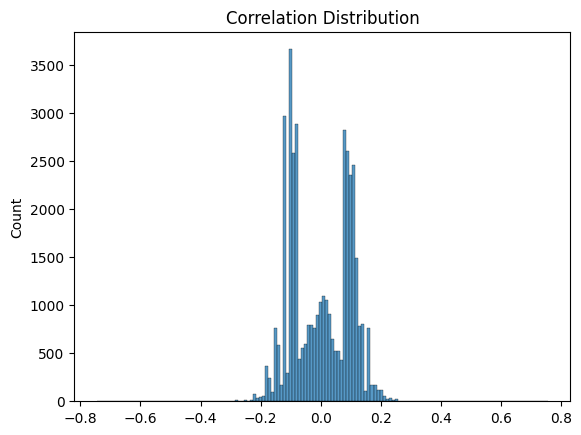

In [17]:
sns.histplot(df_corr.values.flatten(), binwidth=0.01).set_title("Correlation Distribution")

Text(0.5, 1.0, 'Correlation Distribution')

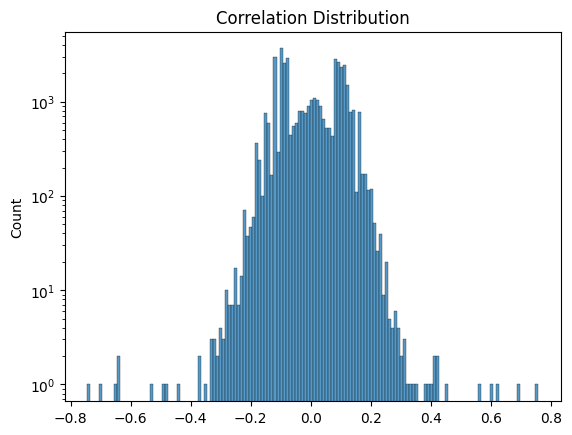

In [18]:
plt = sns.histplot(df_corr.values.flatten(), binwidth=0.01)
plt.set_yscale("log")
plt.set_title("Correlation Distribution")

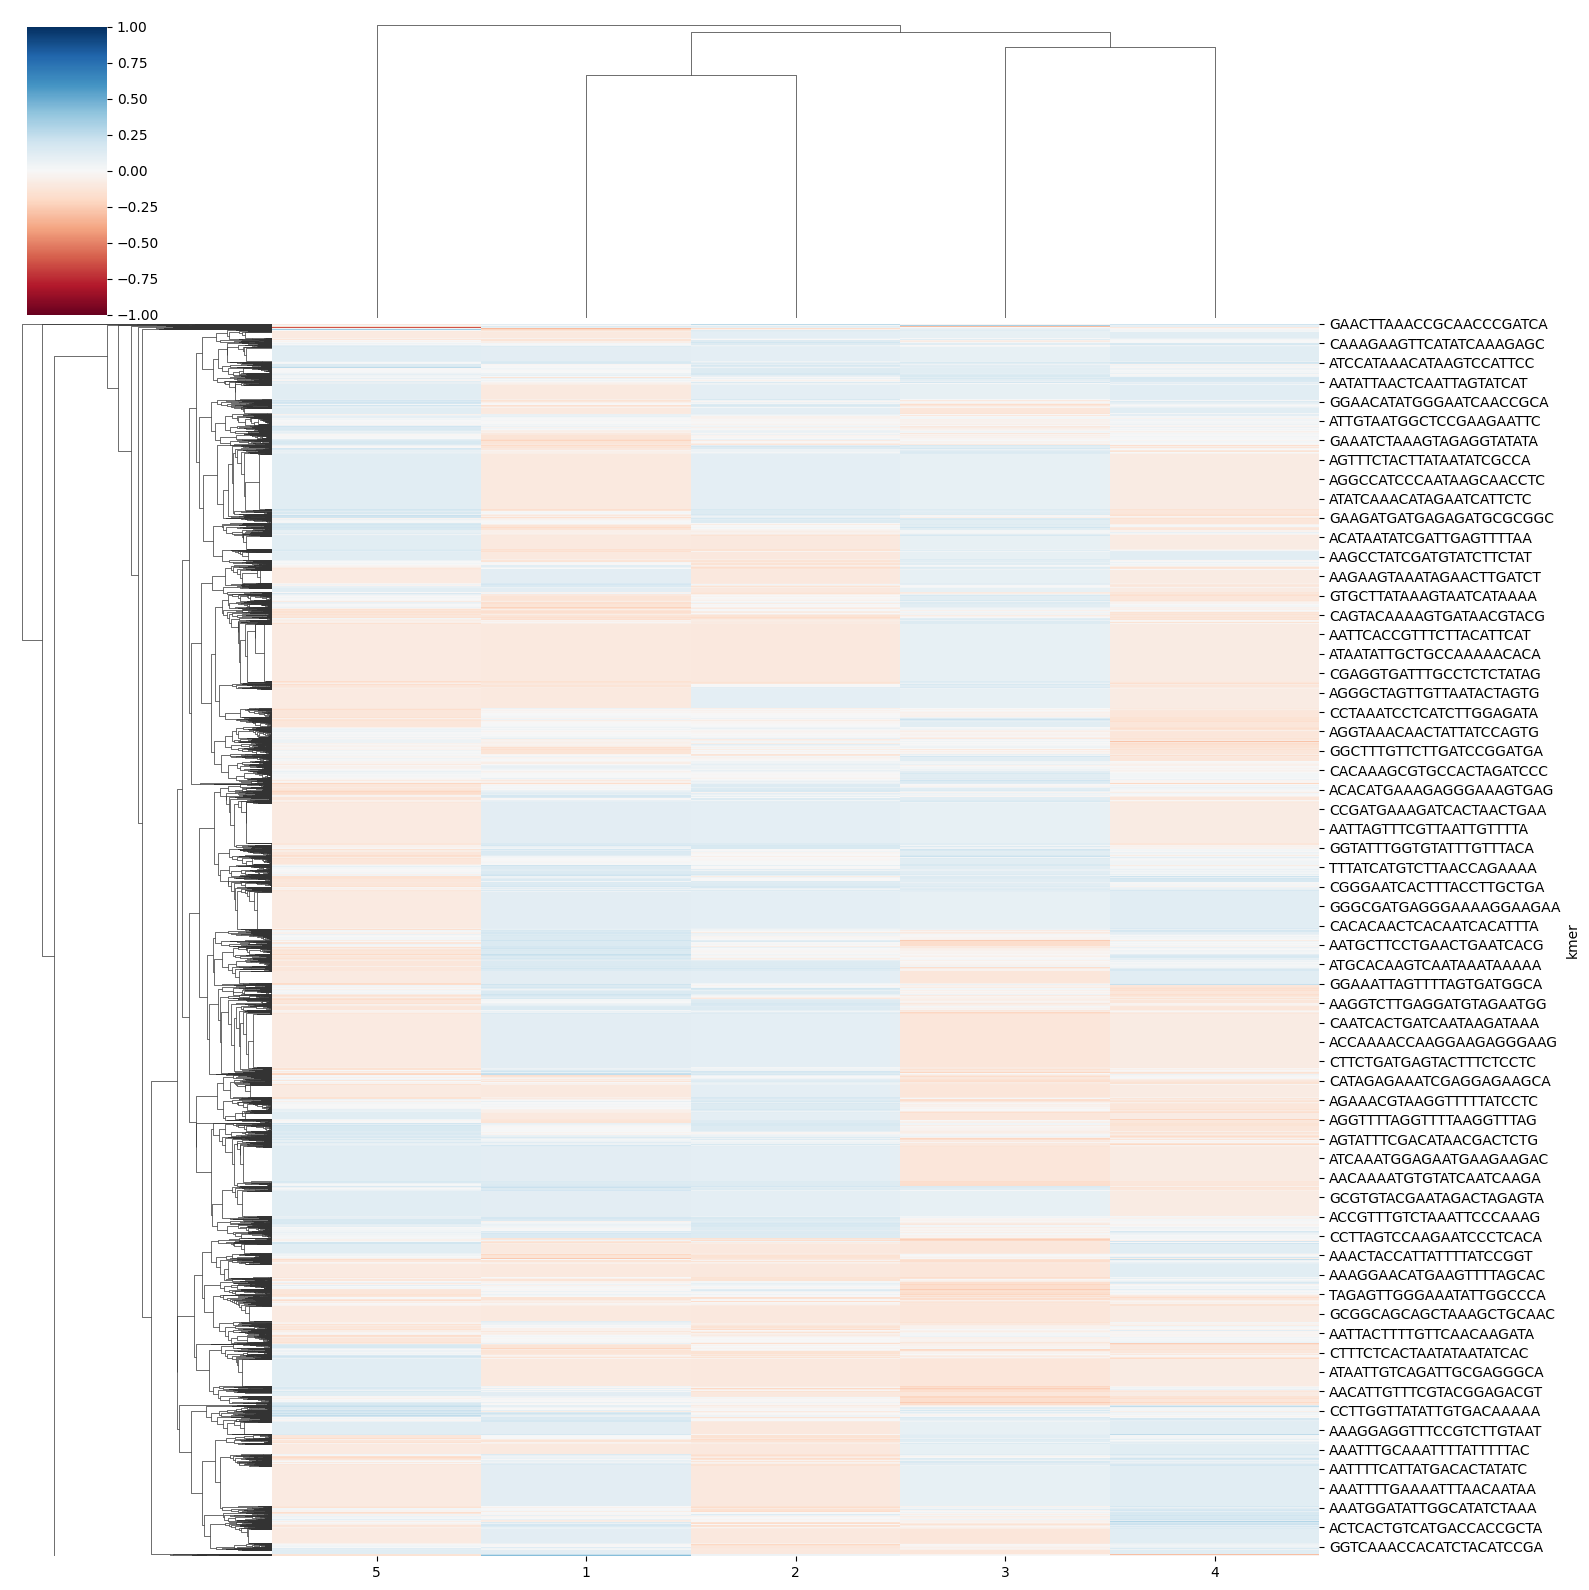

In [19]:
sns.clustermap(
    df_corr,
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)

### Official Analysis

In [21]:
# find kmers that exists in both populations
def find_common_kmers(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.Index:
    print(f"Finding common kmers between {df1.shape[0]} and {df2.shape[0]} kmers")
    common_kmers = df1.index.intersection(df2.index)
    print(f"Found {len(common_kmers)} common kmers")
    return common_kmers

In [22]:
common_kmers = find_common_kmers(
    pd.read_feather('../data/hamburg/joined-counts/Col_ColLer.joined.index.feather', columns=['kmer']),
    pd.read_feather('../data/hamburg/joined-counts/ColLer_Col.joined.index.feather', columns=['kmer']),
)

Finding common kmers between 76263426 and 57974513 kmers
Found 43533202 common kmers
Found 43533202 common kmers


### Assembly Diff joining Hamburg

In [3]:
df_asm = pd.read_feather("../data/assemblies/assembly-diff-lt4-ge10.feather", columns=['kmer'])
df_asm.shape

(229669, 0)

In [4]:
df_tmp = pd.read_feather(
    "../data/hamburg/joined-counts/Col_ColLer.joined.index.feather",
    columns=["kmer"],
)
df_tmp.shape

(76263426, 0)

In [5]:
kmers = df_asm.index.intersection(df_tmp.index)
len(kmers)

226600

In [6]:
df_tmp = pd.read_feather(
    '../data/hamburg/joined-counts/ColLer_Col.joined.index.feather',
    columns=["kmer"],
)
df_tmp.shape

(57974513, 0)

In [7]:
kmers = kmers.intersection(df_tmp.index)
len(kmers)

226270

In [9]:
for i in [1, 2]:
    df_corr = correlate_kmers_with_genotypes(
        metadata_csv_path='../PRJNA723952.SraRunTable.csv',
        genotype_csv_path='../data/hamburg/cen-genotypes/C_LC.cen-genotype.csv',
        kmer_count_feather_path=f'../data/hamburg/joined-counts/Col_ColLer.joined.part.{i}.feather',
        kmer_filter=lambda df: df[df.index.isin(kmers)],
    )

    print(df_corr.shape)
    df_corr.to_feather(f'../data/hamburg/C_LC.corr.part.{i}.feather')

for i in [1, 2]:
    df_corr = correlate_kmers_with_genotypes(
        metadata_csv_path='../PRJNA723952.SraRunTable.csv',
        genotype_csv_path='../data/hamburg/cen-genotypes/LC_C.cen-genotype.csv',
        kmer_count_feather_path=f'../data/hamburg/joined-counts/ColLer_Col.joined.part.{i}.feather',
        kmer_filter=lambda df: df[df.index.isin(kmers)],
    )

    print(df_corr.shape)
    df_corr.to_feather(f'../data/hamburg/LC_C.corr.part.{i}.feather')

(113251, 5)
(112994, 5)
(112994, 5)
(113261, 5)
(113261, 5)
(113009, 5)
(113009, 5)


In [10]:
df_corr_c_lc = pd.concat(
    pd.read_feather(f'../data/hamburg/C_LC.corr.part.{i}.feather') for i in [1, 2]
)
df_corr_c_lc.shape

(226245, 5)

In [11]:
df_corr_lc_c = pd.concat(
    pd.read_feather(f'../data/hamburg/LC_C.corr.part.{i}.feather') for i in [1, 2]
)
df_corr_lc_c.shape

(226270, 5)

In [16]:
df_corr_joined = df_corr_c_lc.join(
    df_corr_lc_c,
    how='inner',
    lsuffix='_c_lc',
    rsuffix='_lc_c',
)
print(df_corr_joined.shape)
df_corr_joined.head()

(226245, 10)


,1_c_lc,2_c_lc,3_c_lc,4_c_lc,5_c_lc,1_lc_c,2_lc_c,3_lc_c,4_lc_c,5_lc_c
kmer,,,,,,,,,,
AAAAAAAAAAAAAAAAAACCATA,-0.021786,-0.197058,0.222229,-0.130127,-0.047097,0.010316,0.054178,0.067925,0.044943,0.005865
AAAAAAAAAAAAAAAAAACGAGG,0.127445,-0.013111,0.122177,0.497510,-0.178230,0.019322,0.245021,-0.009890,0.302406,0.012196
AAAAAAAAAAAAAAAAAACTCGA,0.171490,0.460093,0.154517,0.199757,-0.159705,0.253758,0.451918,-0.039795,-0.033343,0.108250
AAAAAAAAAAAAAAAAAAGGGAT,-0.152776,-0.090358,-0.137694,-0.503181,0.004958,0.037952,-0.062245,-0.040731,-0.473134,0.030902
AAAAAAAAAAAAAAAAACAGAAG,-0.180460,-0.007684,0.047116,-0.120553,-0.083584,-0.012086,0.078382,0.066017,-0.062197,-0.155756


In [ ]:
df_corr_joined.to_feather('../data/hamburg/C_LC.LC_C.corr.feather')

In [2]:
df_corr_joined = pd.read_feather('../data/hamburg/C_LC.LC_C.corr.feather')

Text(0.5, 1.0, 'Correlation Distribution')

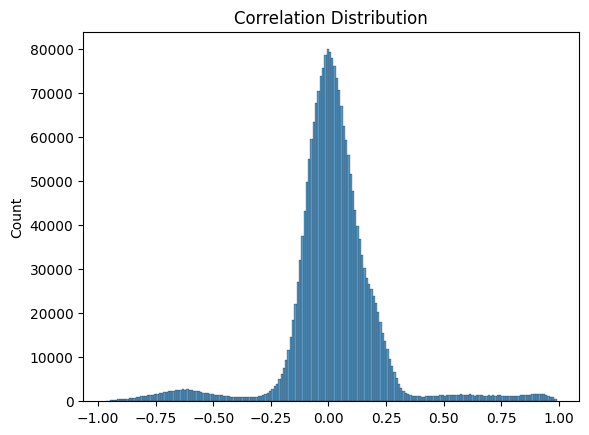

In [3]:
sns.histplot(df_corr_joined.values.flatten(), binwidth=0.01).set_title("Correlation Distribution")

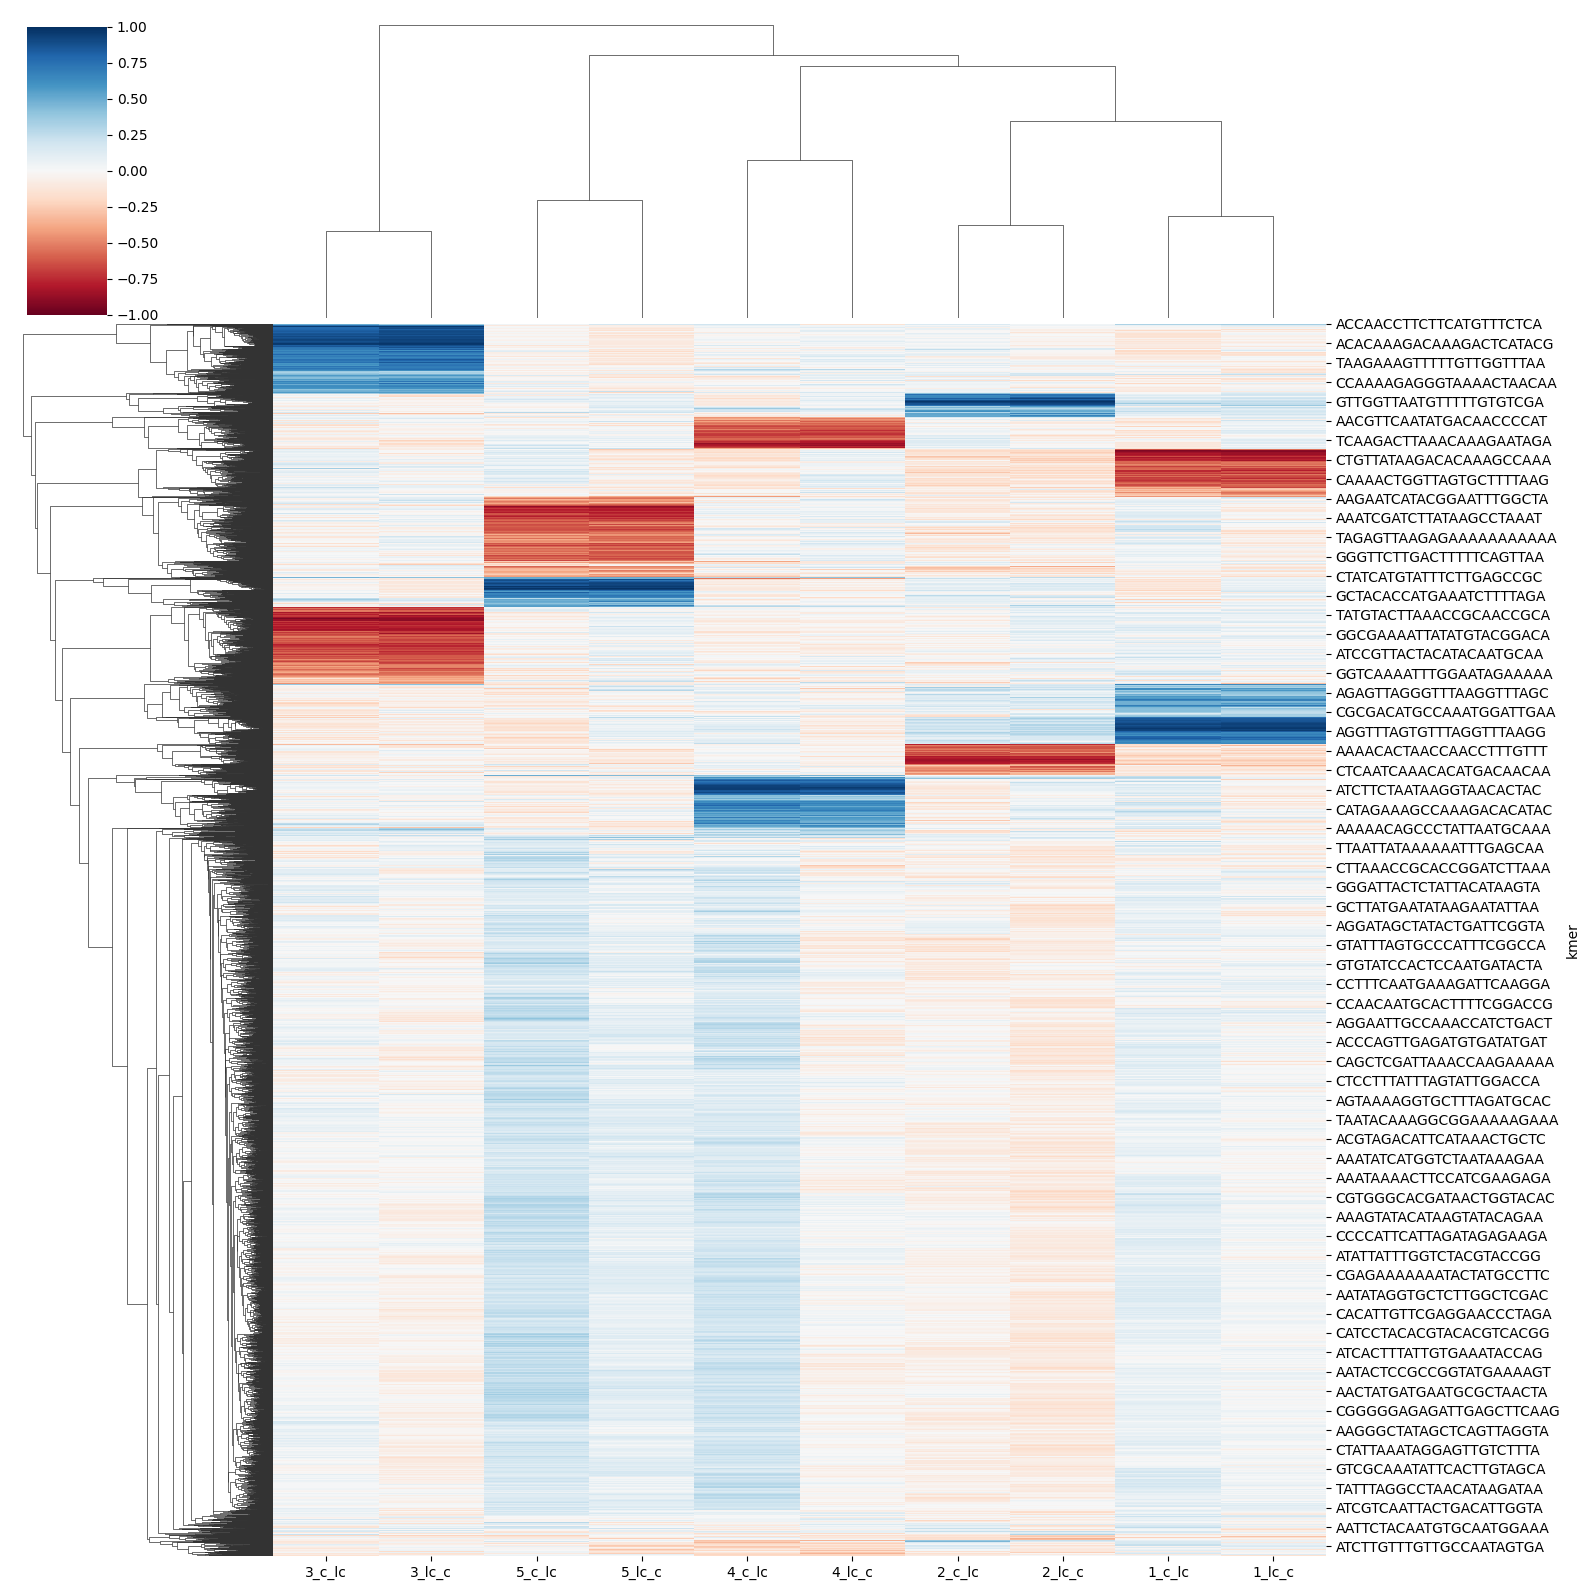

In [18]:
sns.clustermap(
    df_corr_joined.sample(8192),
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)

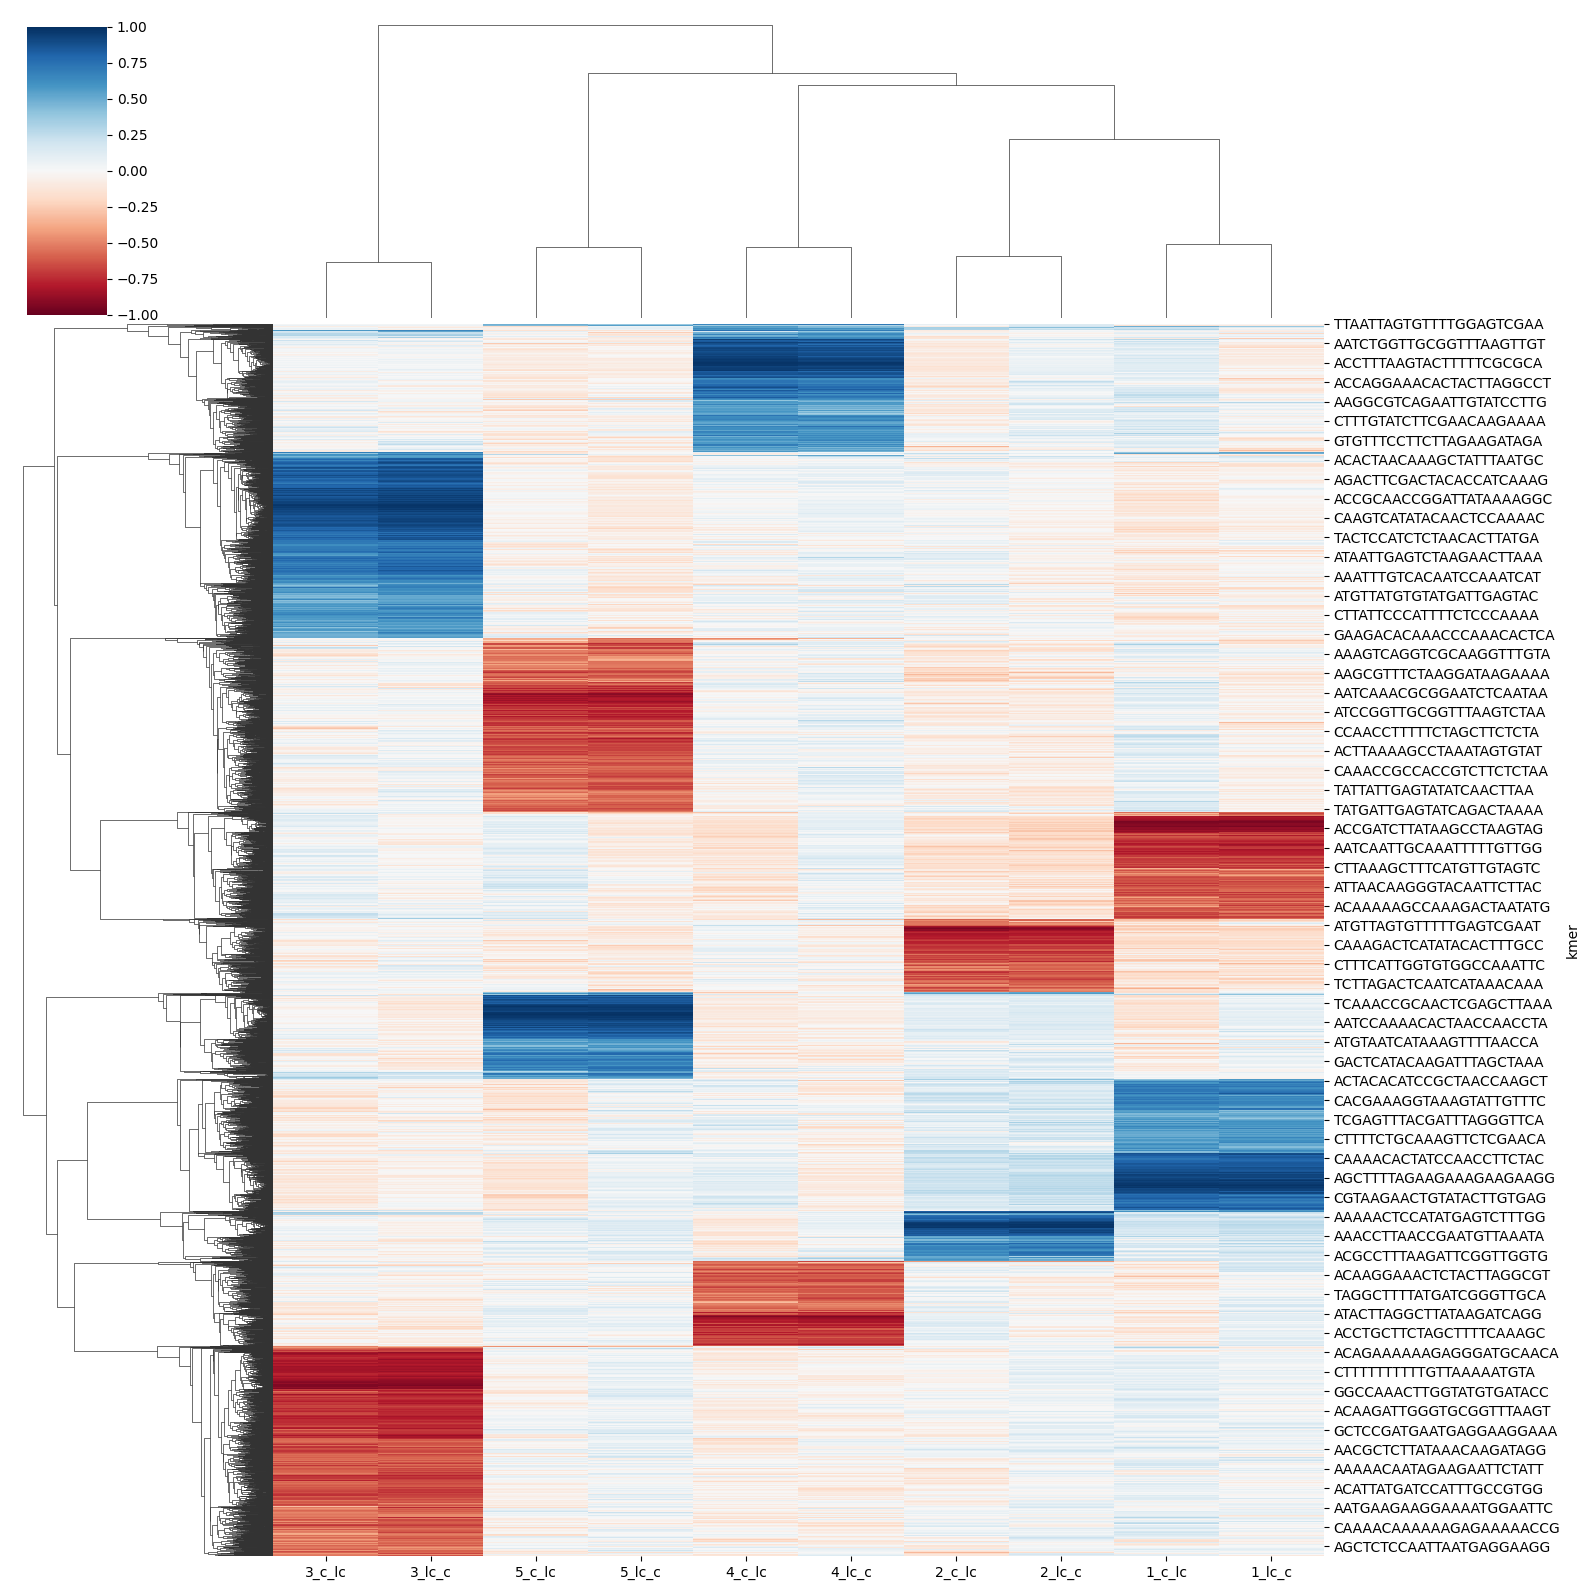

In [19]:
sns.clustermap(
    df_corr_joined[df_corr_joined.abs().max(axis=1) > 0.5].sample(8192),
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)